# EURUSD H4 - MTO v2 Prototypes (Momentum + Mean Reversion)

Ce notebook implemente 2 modules prototypes:

1. **Momentum court terme** sur un seul regresseur de retours normalises par volatilite: \($r^*_{t+1} = \alpha \sum_{j=0}^{k} r^*_{t-j} + \epsilon_{t+1}\), avec \($r^*_t = r_t / \sigma_t\)
2. **Mean Reversion (MR) haut timeframe** autour des niveaux WTO/MTO:
   \($\Delta X_t = \kappa_i (TO_i - X_t) + \epsilon_t\)

Puis on construit un **cadre statistique** pour verifier la significativite (in-sample + test OOS).


In [39]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MetaTrader5 as mt5
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import acf

from metalib.plot_style import use_metalib_style
from metalib.indicators import (
    get_last_monday_6pm_open_ffill,
    get_second_monday_open_ffill,
)

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.6f}'.format
use_metalib_style()


In [41]:
# -------------------------
# Configuration
# -------------------------
SYMBOL = 'EURUSD'
TIMEFRAME = mt5.TIMEFRAME_H1
NUM_BARS = 12_000
CSV_PATH = Path('metalib/data/eurusd/eurusd_h4_latest.csv')
USE_MT5_PULL = True  # True pour forcer un refresh live

MOM_WINDOW = 250          # ~6 semaines H4
MOM_LOOKBACK = 3         # single regressor: sum(r*_t, ..., r*_{t-k})
MOM_VOL_WINDOW = 63       # rolling volatility for return scaling
MOM_ALPHA_SIG = 0.10
MOM_RESID_LAGS = [5, 10, 20]

MR_TIMEFRAME = '1D'       # HTF du module MR
MR_WINDOW = 220           # ~1 an de jours de trading
MR_ALPHA_SIG = 0.10
NUM_TRUE_OPEN_LEVELS = 3  # i=0..2 pour WTO/MTO

TEST_FRAC = 0.30
HAC_LAGS = 5


In [42]:
def pull_mt5_ohlc(symbol: str, timeframe: int, num_bars: int = 10_000):
    if not mt5.initialize():
        raise RuntimeError(f'MT5 initialization failed: {mt5.last_error()}')

    rates = None
    used_symbol = None
    for suffix in ['', '.a', '.b', '.pro', '_SB']:
        test_symbol = f'{symbol}{suffix}'
        pulled = mt5.copy_rates_from_pos(test_symbol, timeframe, 0, num_bars)
        if pulled is not None and len(pulled) > 0:
            rates = pulled
            used_symbol = test_symbol
            break

    if rates is None:
        err = mt5.last_error()
        mt5.shutdown()
        raise RuntimeError(f'No rates returned for {symbol}. Last MT5 error: {err}')

    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s', utc=True)
    df = df[['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']]
    df.sort_values('time', inplace=True)

    mt5.shutdown()
    return df, used_symbol


if USE_MT5_PULL or (not CSV_PATH.exists()):
    df, used_symbol = pull_mt5_ohlc(SYMBOL, TIMEFRAME, NUM_BARS)
    CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CSV_PATH, index=False)
    print(f'Pulled {len(df):,} bars from {used_symbol}')
    print(f'Saved: {CSV_PATH.resolve()}')
else:
    df = pd.read_csv(CSV_PATH)
    df['time'] = pd.to_datetime(df['time'], utc=True)
    df.sort_values('time', inplace=True)
    print(f'Loaded {len(df):,} rows from {CSV_PATH}')

df.tail()

Pulled 12,000 bars from EURUSD
Saved: C:\Users\Hermes\PycharmProjects\metalib\metalib\notebooks\metalib\data\eurusd\eurusd_h4_latest.csv


,time,open,high,low,close,tick_volume,spread,real_volume
11995,2026-05-01 19:00:00+00:00,1.175390,1.175640,1.173700,1.173750,2358,11,0
11996,2026-05-01 20:00:00+00:00,1.173750,1.173980,1.172850,1.173250,1522,11,0
11997,2026-05-01 21:00:00+00:00,1.173250,1.173340,1.171880,1.172670,1888,11,0
11998,2026-05-01 22:00:00+00:00,1.172660,1.172780,1.171730,1.171890,898,11,0
11999,2026-05-01 23:00:00+00:00,1.171890,1.172180,1.171400,1.171400,993,11,0


In [43]:
# Base series H4
ohlc_h4 = df.set_index('time')[['open', 'high', 'low', 'close']].copy()
close_h4 = ohlc_h4['close'].copy()
ret_h4 = np.log(close_h4).diff()

# Daily OHLC pour MTO
ohlc_daily = ohlc_h4.resample('1D').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
}).dropna()

# True opens WTO/MTO (i=0..N-1)
weekly_levels = {
    f'to_w{i}': get_last_monday_6pm_open_ffill(ohlc_h4, ohlc_h4.index, i=i)
    for i in range(NUM_TRUE_OPEN_LEVELS)
}
monthly_levels = {
    f'to_m{i}': get_second_monday_open_ffill(ohlc_daily, ohlc_h4.index, i=i)
    for i in range(NUM_TRUE_OPEN_LEVELS)
}
levels_h4 = pd.concat([pd.DataFrame(weekly_levels), pd.DataFrame(monthly_levels)], axis=1)

display(levels_h4.tail())
print('H4 range:', ohlc_h4.index.min(), '->', ohlc_h4.index.max())
print('Daily bars:', len(ohlc_daily))

,to_w0,to_w1,to_w2,to_m0,to_m1,to_m2
time,,,,,,
2026-05-01 19:00:00+00:00,1.171990,1.145910,1.178860,1.166510,1.154300,1.180900
2026-05-01 20:00:00+00:00,1.171990,1.145910,1.178860,1.166510,1.154300,1.180900
2026-05-01 21:00:00+00:00,1.171990,1.145910,1.178860,1.166510,1.154300,1.180900
2026-05-01 22:00:00+00:00,1.171990,1.145910,1.178860,1.166510,1.154300,1.180900
2026-05-01 23:00:00+00:00,1.171990,1.145910,1.178860,1.166510,1.154300,1.180900


H4 range: 2024-05-28 01:00:00+00:00 -> 2026-05-01 23:00:00+00:00
Daily bars: 501


In [44]:
def rolling_ols_no_intercept(y: pd.Series, x: pd.Series, window: int, min_n=None):
    """Rolling OLS sans constante: y_t = beta * x_t + eps_t.
    Retourne beta, t-stat, p-value, R2, residual std."""
    idx = y.index
    beta = np.full(len(idx), np.nan)
    tval = np.full(len(idx), np.nan)
    pval = np.full(len(idx), np.nan)
    r2 = np.full(len(idx), np.nan)
    resid_std = np.full(len(idx), np.nan)

    if min_n is None:
        min_n = max(40, window // 2)

    for i in range(len(idx)):
        lo = max(0, i - window + 1)
        y_w = y.iloc[lo:i+1]
        x_w = x.iloc[lo:i+1]

        m = y_w.notna() & x_w.notna()
        yv = y_w[m].to_numpy(dtype=float)
        xv = x_w[m].to_numpy(dtype=float)

        n = len(yv)
        if n < min_n:
            continue

        sxx = float(np.dot(xv, xv))
        if sxx <= 1e-12:
            continue

        b = float(np.dot(xv, yv) / sxx)
        resid = yv - b * xv

        dof = n - 1
        if dof <= 0:
            continue

        sse = float(np.dot(resid, resid))
        mse = sse / dof
        se = float(np.sqrt(max(mse / sxx, 1e-16)))

        t = b / se
        p = 2.0 * (1.0 - stats.t.cdf(abs(t), dof))

        ybar = float(np.mean(yv))
        sst = float(np.dot(yv - ybar, yv - ybar))
        rr = np.nan if sst <= 1e-12 else (1.0 - sse / sst)

        beta[i] = b
        tval[i] = t
        pval[i] = p
        r2[i] = rr
        resid_std[i] = float(np.sqrt(mse))

    return pd.DataFrame({
        'beta': beta,
        'tval': tval,
        'pval': pval,
        'r2': r2,
        'resid_std': resid_std,
    }, index=idx)


def eval_one_step_forecast(forecast: pd.Series, next_ret: pd.Series, name: str):
    z = pd.concat([forecast.rename('forecast'), next_ret.rename('next_ret')], axis=1).dropna()
    if len(z) < 50:
        return {'model': name, 'n_obs': len(z)}

    resid = z['next_ret'] - z['forecast']
    sse = float(np.square(resid).sum())
    sst = float(np.square(z['next_ret'] - z['next_ret'].mean()).sum())
    signed_ret = np.sign(z['forecast']) * z['next_ret']
    t_stat, t_p = stats.ttest_1samp(signed_ret.dropna(), popmean=0.0)

    return {
        'model': name,
        'n_obs': int(len(z)),
        'oos_r2_like': np.nan if sst <= 1e-12 else 1.0 - sse / sst,
        'corr': float(z['forecast'].corr(z['next_ret'])),
        'hit_rate': float((np.sign(z['forecast']) == np.sign(z['next_ret'])).mean()),
        'mean_signed_ret': float(signed_ret.mean()),
        't_stat_signed': float(t_stat),
        't_p_signed': float(t_p),
        'mae': float(np.abs(resid).mean()),
        'rmse': float(np.sqrt(np.square(resid).mean())),
    }


# -------------------------
# Module 1: Momentum quality
# Single variable in volatility units:
# x_t = sum(r*_t, r*_{t-1}, ..., r*_{t-k}), where r*_t = r_t / sigma_t
# Regression target: r*_{t+1} = r_{t+1} / sigma_t
# Raw forecast used downstream: forecast(r_{t+1}) = forecast(r*_{t+1}) * sigma_t
# -------------------------
next_ret_h4 = ret_h4.shift(-1)

mom_vol = ret_h4.rolling(
    MOM_VOL_WINDOW,
    min_periods=max(20, MOM_VOL_WINDOW // 2),
).std()
mom_vol = mom_vol.replace(0.0, np.nan)

ret_h4_scaled = ret_h4 / mom_vol
next_ret_h4_scaled = next_ret_h4 / mom_vol
mom_factor = ret_h4_scaled.rolling(
    MOM_LOOKBACK + 1,
    min_periods=MOM_LOOKBACK + 1,
).sum()

mom_ar1 = rolling_ols_no_intercept(
    y=ret_h4 / mom_vol.shift(1),
    x=ret_h4_scaled.shift(1),
    window=MOM_WINDOW,
)

mom_est = rolling_ols_no_intercept(
    y=ret_h4 / mom_vol.shift(1),
    x=mom_factor.shift(1),
    window=MOM_WINDOW,
)

mom = mom_est.rename(columns={
    'beta': 'alpha',
    'tval': 'alpha_t',
    'pval': 'alpha_p',
    'r2': 'alpha_r2',
    'resid_std': 'alpha_resid_std_scaled',
})
mom['mom_vol'] = mom_vol
mom['ret_scaled'] = ret_h4_scaled
mom['next_ret_scaled'] = next_ret_h4_scaled
mom['mom_factor'] = mom_factor

# Baseline AR(1), also fitted in volatility units.
mom['alpha_ar1'] = mom_ar1['beta']
mom['alpha_ar1_t'] = mom_ar1['tval']
mom['alpha_ar1_p'] = mom_ar1['pval']
mom['alpha_ar1_r2'] = mom_ar1['r2']
mom['ar1_forecast_scaled'] = mom['alpha_ar1'] * mom['ret_scaled']
mom['ar1_forecast'] = mom['ar1_forecast_scaled'] * mom['mom_vol']

# Downstream interface used by the evaluation cells.
mom['mom_forecast_scaled'] = mom['alpha'] * mom['mom_factor']
mom['mom_forecast'] = mom['mom_forecast_scaled'] * mom['mom_vol']
mom['mom_score'] = mom['mom_forecast_scaled'] / mom['alpha_resid_std_scaled']
mom['mom_signal'] = np.sign(mom['mom_forecast_scaled'])
mom.loc[mom['alpha_p'] >= MOM_ALPHA_SIG, 'mom_signal'] = 0.0

forecast_comparison = pd.DataFrame([
    eval_one_step_forecast(mom['ar1_forecast'], next_ret_h4, 'Vol-scaled AR(1), no intercept'),
    eval_one_step_forecast(mom['mom_forecast'], next_ret_h4, f'Vol-scaled lookback sum k={MOM_LOOKBACK}, no intercept'),
]).set_index('model')

scaled_forecast_comparison = pd.DataFrame([
    eval_one_step_forecast(mom['ar1_forecast_scaled'], next_ret_h4_scaled, 'Scaled AR(1), no intercept'),
    eval_one_step_forecast(mom['mom_forecast_scaled'], next_ret_h4_scaled, f'Scaled lookback sum k={MOM_LOOKBACK}, no intercept'),
]).set_index('model')

display(forecast_comparison)
display(scaled_forecast_comparison)
display(mom[['alpha_ar1', 'alpha', 'alpha_t', 'alpha_p', 'alpha_r2', 'mom_vol', 'mom_factor', 'mom_forecast_scaled', 'mom_forecast', 'mom_score', 'mom_signal']].tail())
print('Last vol-scaled alpha:', float(mom['alpha'].dropna().iloc[-1]))
print('Last vol-scaled lookback factor:', float(mom['mom_factor'].dropna().iloc[-1]))
print('Last raw momentum forecast:', float(mom['mom_forecast'].dropna().iloc[-1]))


,n_obs,oos_r2_like,corr,hit_rate,mean_signed_ret,t_stat_signed,t_p_signed,mae,rmse
model,,,,,,,,,
"Vol-scaled AR(1), no intercept",11843,-0.006596,0.014172,0.500549,0.000008,0.885158,0.376089,0.000607,0.000943
"Vol-scaled lookback sum k=3, no intercept",11840,-0.007479,-0.014954,0.495439,-0.000015,-1.706004,0.088034,0.000607,0.000943


,n_obs,oos_r2_like,corr,hit_rate,mean_signed_ret,t_stat_signed,t_p_signed,mae,rmse
model,,,,,,,,,
"Scaled AR(1), no intercept",11843,-0.004351,0.018740,0.500549,0.010217,1.002949,0.315906,0.729731,1.112837
"Scaled lookback sum k=3, no intercept",11840,-0.005787,-0.004023,0.495439,-0.009547,-0.935594,0.349501,0.729299,1.113487


,alpha_ar1,alpha,alpha_t,alpha_p,alpha_r2,mom_vol,mom_factor,mom_forecast_scaled,mom_forecast,mom_score,mom_signal
time,,,,,,,,,,,
2026-05-01 19:00:00+00:00,-0.023343,0.004486,0.121855,0.903112,0.000007,0.000770,-2.144336,-0.009619,-0.000007,-0.008231,0.000000
2026-05-01 20:00:00+00:00,-0.015170,0.006231,0.169875,0.865247,-0.000056,0.000770,-3.207469,-0.019985,-0.000015,-0.017126,0.000000
2026-05-01 21:00:00+00:00,-0.024099,0.008834,0.244279,0.807216,-0.000351,0.000773,-4.460145,-0.039400,-0.000030,-0.034074,0.000000
2026-05-01 22:00:00+00:00,-0.021837,0.012589,0.350395,0.726339,-0.000233,0.000778,-3.906208,-0.049174,-0.000038,-0.042484,0.000000
2026-05-01 23:00:00+00:00,-0.020102,0.014017,0.391843,0.695509,-0.000254,0.000778,-2.586066,-0.036249,-0.000028,-0.031308,0.000000


Last vol-scaled alpha: 0.014016916133145823
Last vol-scaled lookback factor: -2.5860657343352225
Last raw momentum forecast: -2.8195677486224395e-05


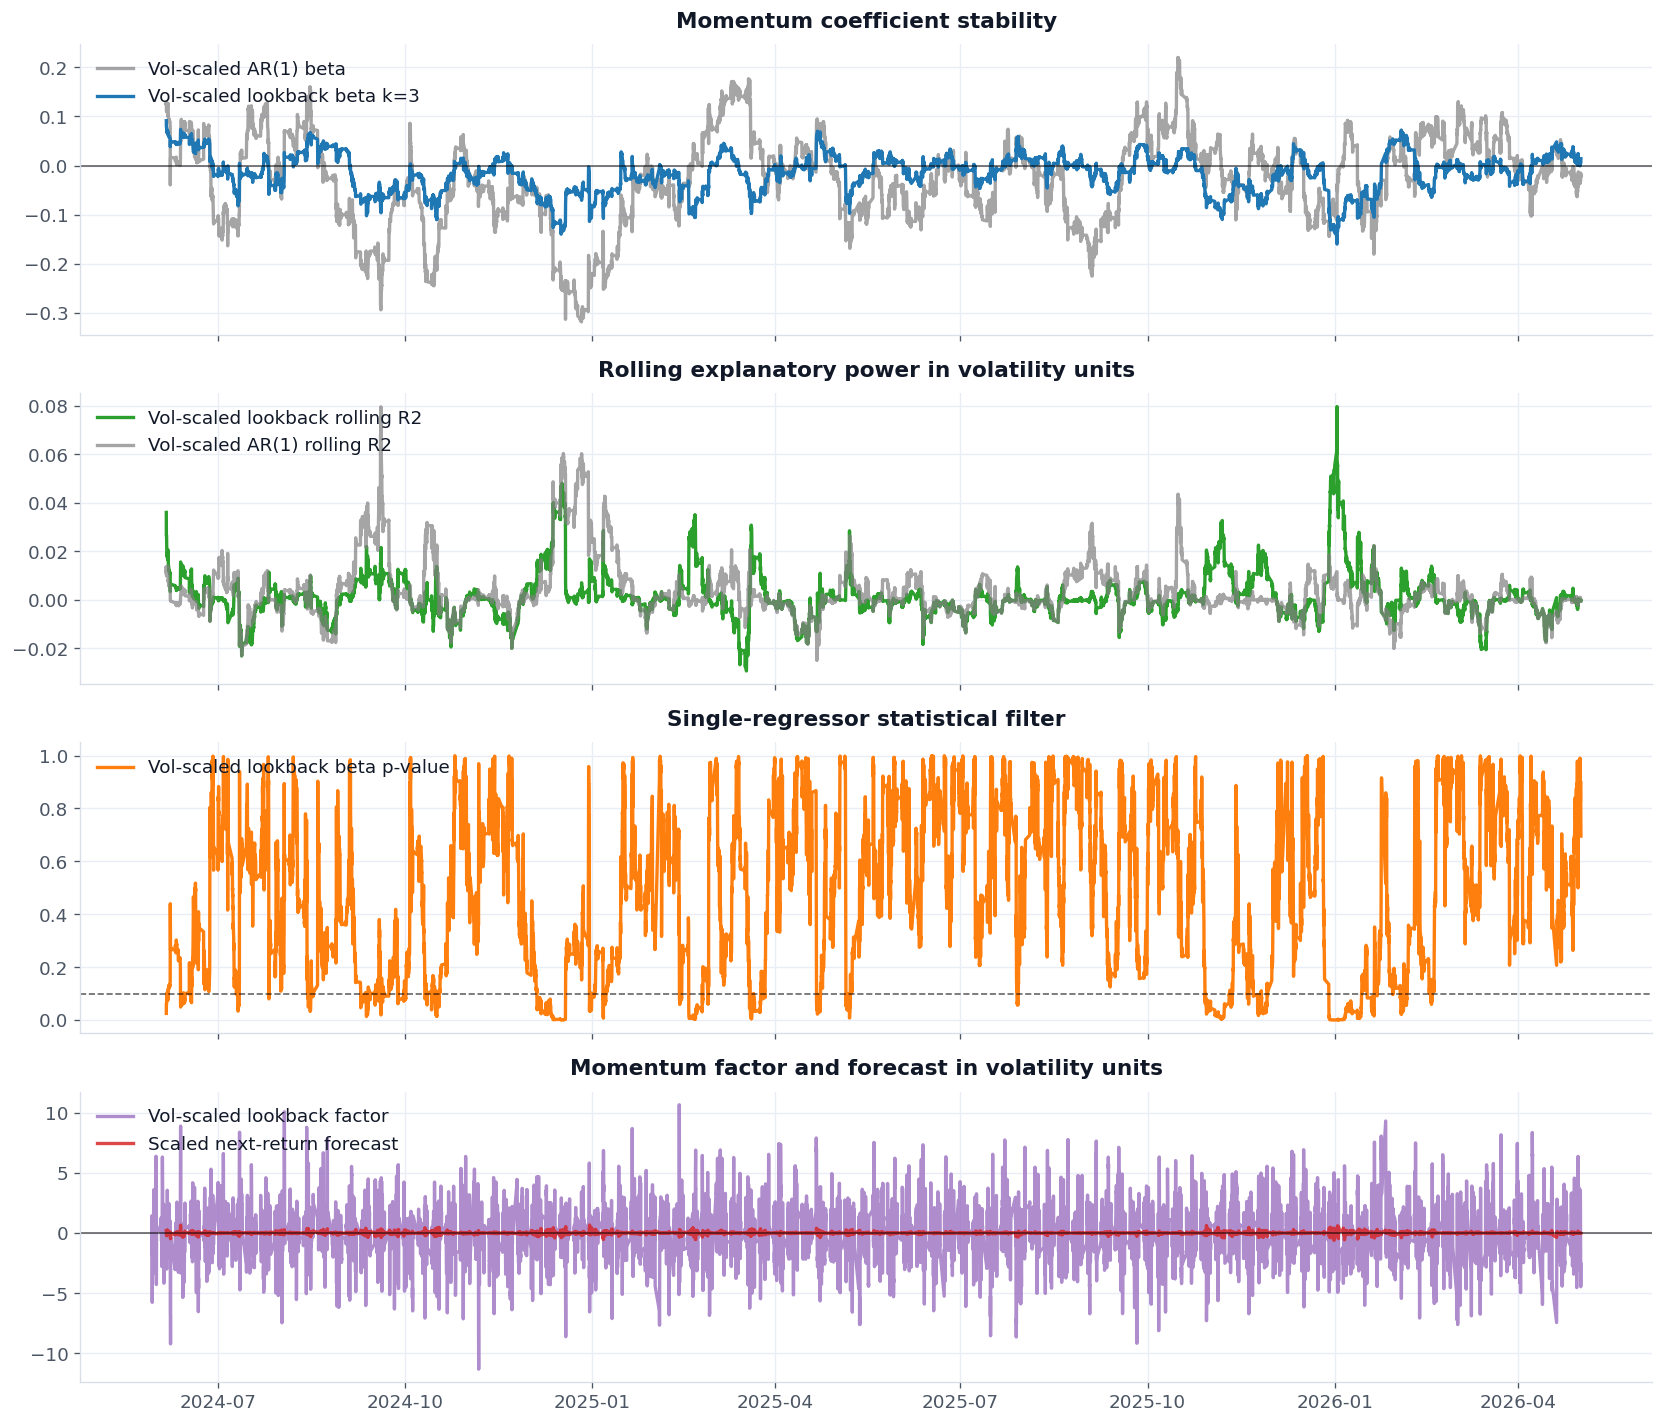

In [46]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(mom.index, mom['alpha_ar1'], label='Vol-scaled AR(1) beta', color='tab:gray', alpha=0.7)
axes[0].plot(mom.index, mom['alpha'], label=f'Vol-scaled lookback beta k={MOM_LOOKBACK}', color='tab:blue')
axes[0].axhline(0, color='black', lw=1, alpha=0.6)
axes[0].set_title('Momentum coefficient stability')
axes[0].legend(loc='upper left')

axes[1].plot(mom.index, mom['alpha_r2'], label='Vol-scaled lookback rolling R2', color='tab:green')
axes[1].plot(mom.index, mom['alpha_ar1_r2'], label='Vol-scaled AR(1) rolling R2', color='tab:gray', alpha=0.7)
axes[1].set_title('Rolling explanatory power in volatility units')
axes[1].legend(loc='upper left')

axes[2].plot(mom.index, mom['alpha_p'], label='Vol-scaled lookback beta p-value', color='tab:orange')
axes[2].axhline(MOM_ALPHA_SIG, color='black', lw=1, alpha=0.6, linestyle='--')
axes[2].set_title('Single-regressor statistical filter')
axes[2].legend(loc='upper left')

axes[3].plot(mom.index, mom['mom_factor'], label='Vol-scaled lookback factor', color='tab:purple', alpha=0.75)
axes[3].plot(mom.index, mom['mom_forecast_scaled'], label='Scaled next-return forecast', color='tab:red', alpha=0.85)
axes[3].axhline(0, color='black', lw=1, alpha=0.6)
axes[3].set_title('Momentum factor and forecast in volatility units')
axes[3].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [33]:
def residual_diagnostics(resid: pd.Series, name: str):
    clean = resid.dropna()
    jb_stat, jb_p, skew, kurt = jarque_bera(clean)
    arch_stat, arch_p, _, _ = het_arch(clean, nlags=min(12, max(1, len(clean) // 20)))
    lb = acorr_ljungbox(clean, lags=MOM_RESID_LAGS, return_df=True)

    row = {
        'model': name,
        'n_obs': int(len(clean)),
        'mean': float(clean.mean()),
        'std': float(clean.std()),
        'skew': float(skew),
        'kurtosis': float(kurt),
        'jarque_bera_p': float(jb_p),
        'arch_lm_p': float(arch_p),
    }
    for lag in MOM_RESID_LAGS:
        row[f'ljung_box_p_lag_{lag}'] = float(lb.loc[lag, 'lb_pvalue'])
    return row

mom_residuals = pd.DataFrame(index=ohlc_h4.index)
mom_residuals['next_ret'] = next_ret_h4
mom_residuals['next_ret_scaled'] = next_ret_h4_scaled
mom_residuals['ar1_resid'] = next_ret_h4 - mom['ar1_forecast']
mom_residuals['lookback_resid'] = next_ret_h4 - mom['mom_forecast']
mom_residuals['ar1_resid_scaled'] = next_ret_h4_scaled - mom['ar1_forecast_scaled']
mom_residuals['lookback_resid_scaled'] = next_ret_h4_scaled - mom['mom_forecast_scaled']

resid_report = pd.DataFrame([
    residual_diagnostics(mom_residuals['ar1_resid_scaled'], 'Scaled AR(1) residual'),
    residual_diagnostics(mom_residuals['lookback_resid_scaled'], f'Scaled lookback k={MOM_LOOKBACK} residual'),
]).set_index('model')

display(resid_report)

flag_row = resid_report.loc[f'Scaled lookback k={MOM_LOOKBACK} residual']
diagnostic_flags = pd.Series({
    'fat_tails_or_non_normal': flag_row['jarque_bera_p'] < 0.05,
    'remaining_autocorrelation': min(flag_row[f'ljung_box_p_lag_{lag}'] for lag in MOM_RESID_LAGS) < 0.05,
    'conditional_heteroskedasticity': flag_row['arch_lm_p'] < 0.05,
    'non_zero_residual_mean_material': abs(flag_row['mean']) > 0.05 * flag_row['std'],
})
display(diagnostic_flags.rename('diagnostic_flag'))


,n_obs,mean,std,skew,kurtosis,jarque_bera_p,arch_lm_p,ljung_box_p_lag_5,ljung_box_p_lag_10,ljung_box_p_lag_20
model,,,,,,,,,,
Scaled AR(1) residual,11843,0.005918,1.112868,-0.026691,17.998241,0.000000,0.006179,0.154586,0.384275,0.750977
Scaled lookback k=12 residual,11831,-0.000302,1.112697,-0.035963,18.363939,0.000000,0.027273,0.010712,0.048026,0.301805


fat_tails_or_non_normal             True
remaining_autocorrelation           True
conditional_heteroskedasticity      True
non_zero_residual_mean_material    False
Name: diagnostic_flag, dtype: bool

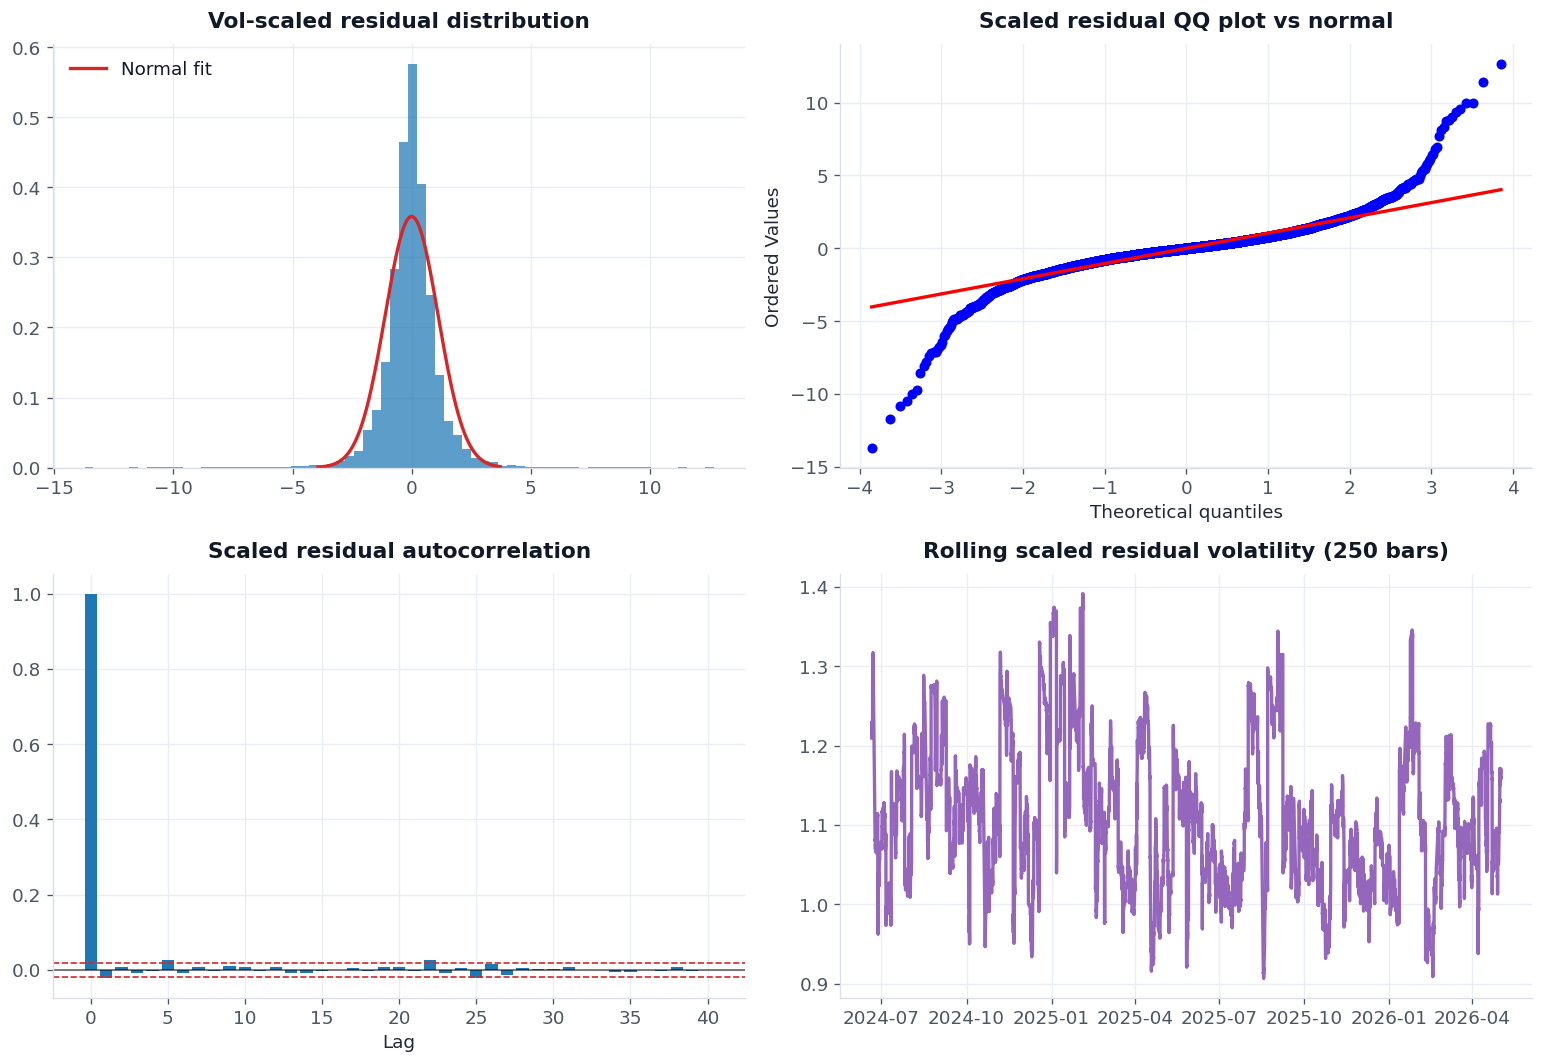

In [34]:
clean_resid = mom_residuals['lookback_resid_scaled'].dropna()
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(clean_resid, bins=70, density=True, alpha=0.72, color='tab:blue')
xs = np.linspace(clean_resid.quantile(0.005), clean_resid.quantile(0.995), 300)
axes[0, 0].plot(xs, stats.norm.pdf(xs, clean_resid.mean(), clean_resid.std()), color='tab:red', lw=2, label='Normal fit')
axes[0, 0].set_title('Vol-scaled residual distribution')
axes[0, 0].legend(loc='upper left')

stats.probplot(clean_resid, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Scaled residual QQ plot vs normal')

acf_vals = acf(clean_resid, nlags=40, fft=True)
axes[1, 0].bar(np.arange(len(acf_vals)), acf_vals, color='tab:blue')
conf = 1.96 / np.sqrt(len(clean_resid))
axes[1, 0].axhline(0, color='black', lw=1, alpha=0.6)
axes[1, 0].axhline(conf, color='tab:red', linestyle='--', lw=1)
axes[1, 0].axhline(-conf, color='tab:red', linestyle='--', lw=1)
axes[1, 0].set_title('Scaled residual autocorrelation')
axes[1, 0].set_xlabel('Lag')

axes[1, 1].plot(clean_resid.index, clean_resid.rolling(MOM_WINDOW).std(), color='tab:purple')
axes[1, 1].set_title(f'Rolling scaled residual volatility ({MOM_WINDOW} bars)')

plt.tight_layout()
plt.show()


## Momentum Model Notes

- The momentum module remains a one-variable regression. The regressor is now the cumulative volatility-scaled return over the last `MOM_LOOKBACK + 1` bars: `sum(r*_t, ..., r*_t-k)`.
- The fitted target is also in volatility units: `r*_{t+1} = r_{t+1} / sigma_t`. The notebook converts the scaled forecast back to raw return with `mom_forecast = mom_forecast_scaled * mom_vol` so the downstream signal evaluation remains unchanged.
- If this improves residual stability versus AR(1), it means the old model was partly learning volatility regimes rather than directional persistence.
- If `fat_tails_or_non_normal` is still true after scaling, the tails are not just volatility clustering. Try winsorised scaled returns or Huber regression.
- If `remaining_autocorrelation` is true, compare fixed horizons such as 3, 6, 12, 24 bars or use an exponentially weighted lookback factor.
- If `conditional_heteroskedasticity` remains true, replace rolling std with EWMA volatility or ATR/range volatility. Rolling std can lag regime shifts.
- If `non_zero_residual_mean_material` is true repeatedly, test the same regression with an intercept. Keep no-intercept as the first live candidate unless the intercept survives OOS.

Relevant papers to skim:

- Lo and MacKinlay, "Stock Market Prices Do Not Follow Random Walks". Useful framing for short-horizon return autocorrelation.
- Jegadeesh and Titman, "Returns to Buying Winners and Selling Losers". Classic momentum reference, though cross-sectional rather than single-asset.
- Moskowitz, Ooi, and Pedersen, "Time Series Momentum". Closest to this module conceptually: own past returns forecasting a market's next return.
- Hurst, Ooi, and Pedersen, "A Century of Evidence on Trend-Following Investing". Practical long-run trend-following robustness reference.


In [35]:
# -------------------------
# Module 2: MR quality sur HTF
# Delta X_t = kappa_i * (TO_i - X_t) + eps_t
# -------------------------
ohlc_htf = ohlc_h4.resample(MR_TIMEFRAME).agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
}).dropna()
close_htf = ohlc_htf['close']

# Reindex des niveaux H4 vers HTF
levels_htf = levels_h4.reindex(close_htf.index, method='ffill')

mr_cols = []
mr_data = {}

for col in levels_htf.columns:
    # Estimation en mode causal (historiques connus):
    # y_t = X_t - X_{t-1}, x_t = TO_{t-1} - X_{t-1}
    y_hist = close_htf.diff()
    x_hist = levels_htf[col].shift(1) - close_htf.shift(1)

    est = rolling_ols_no_intercept(y=y_hist, x=x_hist, window=MR_WINDOW)

    kappa_col = f'{col}_kappa'
    t_col = f'{col}_kappa_t'
    p_col = f'{col}_kappa_p'
    force_col = f'{col}_force'
    force_sig_col = f'{col}_force_sig'

    mr_data[kappa_col] = est['beta']
    mr_data[t_col] = est['tval']
    mr_data[p_col] = est['pval']

    force_now = est['beta'] * (levels_htf[col] - close_htf)
    mr_data[force_col] = force_now
    mr_data[force_sig_col] = force_now.where(est['pval'] < MR_ALPHA_SIG, 0.0)

    mr_cols.append((col, kappa_col, t_col, p_col, force_col, force_sig_col))

mr_htf = pd.DataFrame(mr_data, index=close_htf.index)
force_sig_cols = [c[-1] for c in mr_cols]
mr_htf['mr_force'] = mr_htf[force_sig_cols].sum(axis=1, min_count=1)
mr_htf['mr_signal'] = np.sign(mr_htf['mr_force'])

# Summary des kappas les plus recents
rows = []
for base, k_col, t_col, p_col, _, _ in mr_cols:
    last_idx = mr_htf[k_col].dropna().index.max()
    if pd.isna(last_idx):
        continue
    k = float(mr_htf.loc[last_idx, k_col])
    t = float(mr_htf.loc[last_idx, t_col])
    p = float(mr_htf.loc[last_idx, p_col])
    relation = 'attractor' if k > 0 else 'repulsor'
    rows.append({
        'level': base,
        'kappa': k,
        't_stat': t,
        'p_value': p,
        'relation': relation,
        'signif_10pct': p < MR_ALPHA_SIG,
    })

kappa_summary = pd.DataFrame(rows).sort_values('level')
display(kappa_summary)

# Forward-fill vers H4 pour fusion avec module momentum
mr_h4 = mr_htf[['mr_force', 'mr_signal']].reindex(ohlc_h4.index, method='ffill')
mr_h4.tail()

,level,kappa,t_stat,p_value,relation,signif_10pct
3,to_m0,0.046872,1.824687,0.069411,attractor,True
4,to_m1,0.027726,1.868366,0.063046,attractor,True
5,to_m2,0.018389,1.283797,0.200570,attractor,False
0,to_w0,0.008499,0.403881,0.686694,attractor,False
1,to_w1,0.021782,1.337048,0.182594,attractor,False
2,to_w2,0.020671,1.470162,0.142953,attractor,False


,mr_force,mr_signal
time,,
2026-05-01 19:00:00+00:00,-0.000703,-1.000000
2026-05-01 20:00:00+00:00,-0.000703,-1.000000
2026-05-01 21:00:00+00:00,-0.000703,-1.000000
2026-05-01 22:00:00+00:00,-0.000703,-1.000000
2026-05-01 23:00:00+00:00,-0.000703,-1.000000


In [37]:
def _binom_pvalue_greater(k: int, n: int, p0: float = 0.5):
    if n <= 0:
        return np.nan
    try:
        return stats.binomtest(k, n, p=p0, alternative='greater').pvalue
    except AttributeError:
        return stats.binom_test(k, n, p=p0, alternative='greater')


def eval_signal(signal: pd.Series, next_ret: pd.Series, name: str, hac_lags: int = 5):
    z = pd.concat([signal.rename('signal'), next_ret.rename('next_ret')], axis=1).dropna()
    z = z[z['signal'] != 0]

    if len(z) < 50:
        return {
            'name': name,
            'n_obs': len(z),
            'hit_rate': np.nan,
            'binom_p': np.nan,
            'mean_signed_ret': np.nan,
            't_stat_signed': np.nan,
            't_p_signed': np.nan,
            'spearman_ic': np.nan,
            'hac_beta': np.nan,
            'hac_t': np.nan,
            'hac_p': np.nan,
        }

    signed_ret = np.sign(z['signal']) * z['next_ret']
    hits = (signed_ret > 0).astype(int)

    hit_rate = float(hits.mean())
    k = int(hits.sum())
    n = int(len(hits))
    binom_p = float(_binom_pvalue_greater(k, n, p0=0.5))

    t_stat, t_p = stats.ttest_1samp(signed_ret.dropna(), popmean=0.0)
    ic = float(z['signal'].corr(z['next_ret'], method='spearman'))

    try:
        X = sm.add_constant(z['signal'])
        ols = sm.OLS(z['next_ret'], X).fit(cov_type='HAC', cov_kwds={'maxlags': hac_lags})
        beta = float(ols.params['signal'])
        beta_t = float(ols.tvalues['signal'])
        beta_p = float(ols.pvalues['signal'])
    except Exception:
        beta, beta_t, beta_p = np.nan, np.nan, np.nan

    return {
        'name': name,
        'n_obs': n,
        'hit_rate': hit_rate,
        'binom_p': binom_p,
        'mean_signed_ret': float(signed_ret.mean()),
        't_stat_signed': float(t_stat),
        't_p_signed': float(t_p),
        'spearman_ic': ic,
        'hac_beta': beta,
        'hac_t': beta_t,
        'hac_p': beta_p,
    }


# -------------------------
# Fusion des modules + evaluation statistique
# -------------------------
eval_df = pd.DataFrame(index=ohlc_h4.index)
eval_df['next_ret'] = ret_h4.shift(-1)

eval_df['mom_signal'] = mom['mom_signal']
eval_df['mom_score'] = mom['mom_score']

eval_df['mr_signal'] = mr_h4['mr_signal']
eval_df['mr_score'] = mr_h4['mr_force']

# Signal combine: uniquement quand momentum et MR sont alignes
same_side = (np.sign(eval_df['mom_signal']) == np.sign(eval_df['mr_signal'])) & (eval_df['mom_signal'] != 0)
eval_df['combo_signal'] = np.where(same_side, np.sign(eval_df['mom_signal']), 0.0)
eval_df['combo_score'] = eval_df['mom_score'].fillna(0.0) + eval_df['mr_score'].fillna(0.0)

# Split IS / OOS
split_idx = int(len(eval_df) * (1.0 - TEST_FRAC))
is_df = eval_df.iloc[:split_idx].copy()
oos_df = eval_df.iloc[split_idx:].copy()

signal_map = {
    'mom_signal': 'Momentum sign',
    'mr_signal': 'MR force sign',
    'combo_signal': 'Aligned momentum+MR sign',
    'mom_score': 'Momentum continuous score',
    'mr_score': 'MR continuous score',
    'combo_score': 'Combined continuous score',
}

res_is = pd.DataFrame([
    eval_signal(is_df[col], is_df['next_ret'], f'IS | {label}', hac_lags=HAC_LAGS)
    for col, label in signal_map.items()
])

res_oos = pd.DataFrame([
    eval_signal(oos_df[col], oos_df['next_ret'], f'OOS | {label}', hac_lags=HAC_LAGS)
    for col, label in signal_map.items()
])

display(res_is.sort_values('hac_p'))
display(res_oos.sort_values('hac_p'))

,name,n_obs,hit_rate,binom_p,mean_signed_ret,t_stat_signed,t_p_signed,spearman_ic,hac_beta,hac_t,hac_p
4,IS | MR continuous score,336,0.517857,0.274252,0.000066,0.800259,0.424128,0.071307,0.093185,1.353094,0.176026
3,IS | Momentum continuous score,8232,0.488217,0.984195,-0.000016,-1.414600,0.157224,-0.018638,-0.000304,-1.190799,0.233732
5,IS | Combined continuous score,8232,0.487974,0.985861,-0.000017,-1.505116,0.132333,-0.018569,-0.000299,-1.168486,0.242611
1,IS | MR force sign,336,0.517857,0.274252,0.000066,0.800259,0.424128,NaN,0.000066,0.889974,0.373480
0,IS | Momentum sign,490,0.487755,0.721470,-0.000043,-0.775420,0.438466,-0.005504,-0.000039,-0.827150,0.408152
2,IS | Aligned momentum+MR sign,57,0.491228,0.604317,-0.000134,-0.612662,0.542580,NaN,-0.000134,-0.667069,0.504728


,name,n_obs,hit_rate,binom_p,mean_signed_ret,t_stat_signed,t_p_signed,spearman_ic,hac_beta,hac_t,hac_p
4,OOS | MR continuous score,431,0.510441,0.350014,-0.000041,-0.836030,0.403602,-0.065756,-0.113597,-1.193898,0.232518
5,OOS | Combined continuous score,3599,0.497916,0.605149,-0.000007,-0.564939,0.572150,-0.013277,-0.000245,-1.164942,0.244042
3,OOS | Momentum continuous score,3599,0.497638,0.617925,-0.000008,-0.632370,0.527185,-0.013218,-0.000244,-1.160931,0.245670
1,OOS | MR force sign,431,0.510441,0.350014,-0.000041,-0.836030,0.403602,-0.043246,-0.000052,-1.001213,0.316724
0,OOS | Momentum sign,200,0.510000,0.416035,-0.000043,-0.913945,0.361852,-0.038240,-0.000042,-0.813138,0.416139
2,OOS | Aligned momentum+MR sign,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


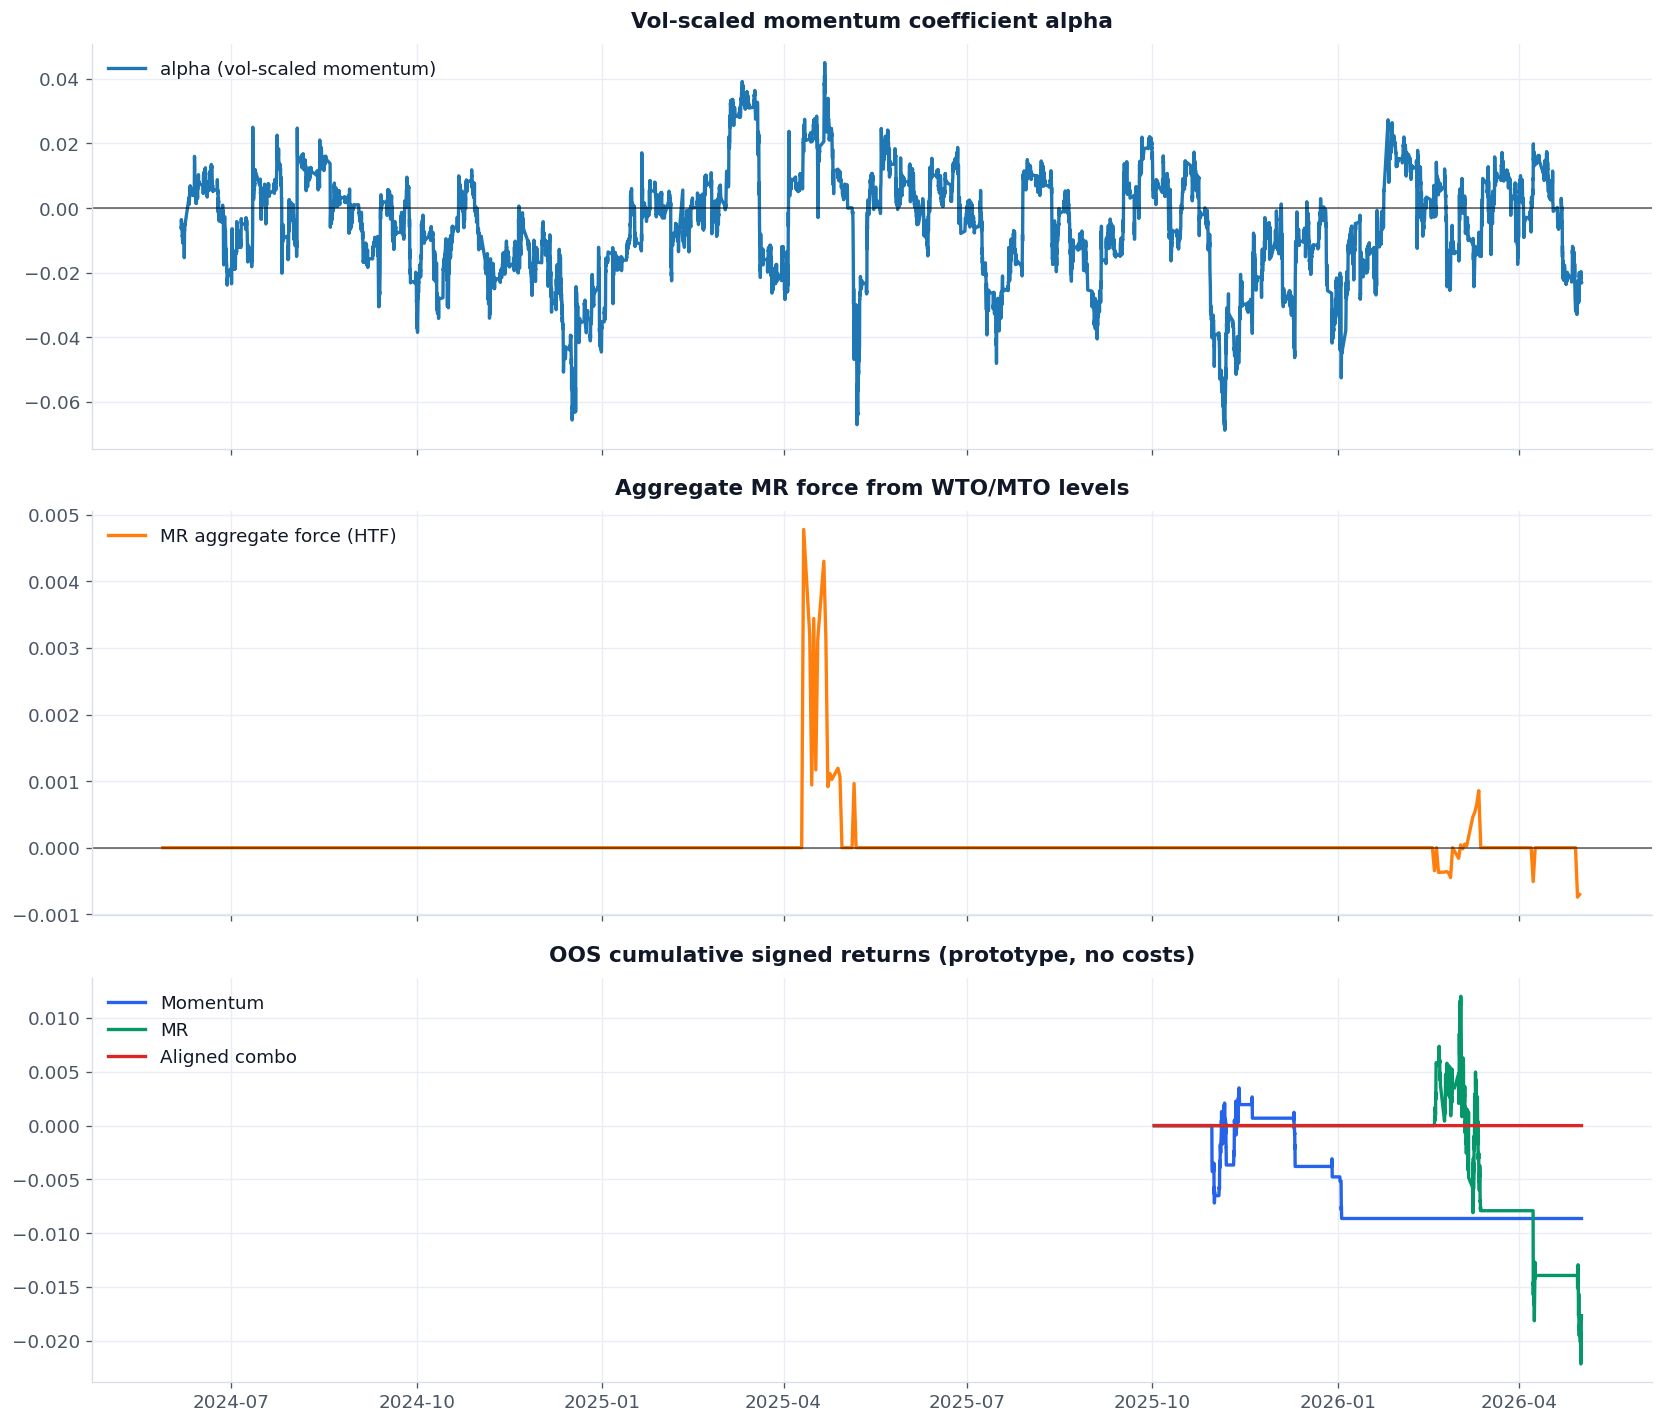

In [38]:
# -------------------------
# Visual diagnostics
# -------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(mom.index, mom['alpha'], label='alpha (vol-scaled momentum)', color='tab:blue')
axes[0].axhline(0, color='black', lw=1, alpha=0.6)
axes[0].set_title('Vol-scaled momentum coefficient alpha')
axes[0].legend(loc='upper left')

axes[1].plot(mr_htf.index, mr_htf['mr_force'], label='MR aggregate force (HTF)', color='tab:orange')
axes[1].axhline(0, color='black', lw=1, alpha=0.6)
axes[1].set_title('Aggregate MR force from WTO/MTO levels')
axes[1].legend(loc='upper left')

test_slice = oos_df.copy()
for col, lab in [('mom_signal', 'Momentum'), ('mr_signal', 'MR'), ('combo_signal', 'Aligned combo')]:
    strat_ret = np.sign(test_slice[col]) * test_slice['next_ret']
    axes[2].plot(strat_ret.fillna(0.0).cumsum(), label=lab)
axes[2].set_title('OOS cumulative signed returns (prototype, no costs)')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()


## Lecture rapide des resultats

- **Momentum**: regarder `alpha`, `alpha_t`, `alpha_p` et la stabilite temporelle.
- **MR**: pour chaque niveau `to_wi/to_mi`, le signe de `kappa` indique attracteur (`kappa>0`) ou repulseur (`kappa<0`).
- **Significativite**:
  - `binom_p` sur hit-rate directionnel (>50%)
  - `t_p_signed` sur la moyenne des signed returns
  - `hac_p` sur regression HAC de `next_ret` sur le signal
- **Validation pragmatique**: privilegier OOS (`OOS | ...`) et robustesse sur plusieurs periodes/market regimes avant integration live.